# 02 - Classification Baseline (EfficientNet)

Train EfficientNet model on durian leaf dataset (Kaggle).

Conventions: 224x224 images, 80/10/10 split, classification metrics monitoring.

In [1]:
import os
import sys
proj_root = r'E:\Master\thesis_durian'
sys.path.insert(0, proj_root)
sys.path.insert(0, os.path.join(proj_root, 'utils'))

import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import transforms
from torch.utils.data import DataLoader as TorchDataLoader
from utils.preprocessing import DataLoader as DurianDataLoader
from utils.models import EfficientNetClassifier
from utils.metrics import ModelEvaluator
from utils.visualization import DurianVisualizer
from tqdm import tqdm

# Device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', device)

device: cpu


## Data Loading

In [2]:
data_loader = DurianDataLoader('data/raw', batch_size=16, image_size=(224,224))
splits = data_loader.load_dataset()
print('Splits count:', {k:len(v) for k,v in splits.items()})
print('Class distribution:', data_loader.get_class_distribution())

train_loader = data_loader.get_data_loader('train', is_training=True)
val_loader = data_loader.get_data_loader('val', is_training=False)
test_loader = data_loader.get_data_loader('test', is_training=False)

Splits count: {'train': 3104, 'val': 443, 'test': 890}
Class distribution: {0: 733, 1: 913, 2: 976, 3: 937, 4: 878}


## Model Initialization

In [3]:
num_classes = len(data_loader.get_class_distribution())
model = EfficientNetClassifier(num_classes=num_classes, backbone='efficientnet_b0', pretrained=True).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', patience=2, factor=0.5)
evaluator = ModelEvaluator(device=device)
visualizer = DurianVisualizer('visualizations/classification')

## Training Loop

In [4]:
epochs = 10
best_val_acc = 0.0
history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
os.makedirs('models/classification/checkpoints', exist_ok=True)

for epoch in range(1, epochs+1):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for batch in tqdm(train_loader, desc=f'Epoch {epoch} [train]'):
        images = batch['image'].to(device)
        labels = batch['label'].to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    train_loss = running_loss / total
    train_acc = correct / total

    model.eval()
    val_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for batch in val_loader:
            images = batch['image'].to(device)
            labels = batch['label'].to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item() * images.size(0)
            _, preds = torch.max(outputs, 1)
            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)

    val_loss = val_loss / val_total
    val_acc = val_correct / val_total

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)

    print(f'Epoch {epoch}/{epochs}: Train loss {train_loss:.4f}, acc {train_acc:.4f} | Val loss {val_loss:.4f}, acc {val_acc:.4f}')
    scheduler.step(val_acc)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save({'model_state_dict': model.state_dict(), 'epoch': epoch, 'val_acc': val_acc}, f'models/classification/checkpoints/efficientnet_baseline_best_{int(val_acc*10000)}.pth')
        print('Saved best model.')

Epoch 1 [train]:   0%|          | 0/194 [00:00<?, ?it/s]

Epoch 1 [train]: 100%|██████████| 194/194 [10:53<00:00,  3.37s/it]


Epoch 1/10: Train loss 1.0893, acc 0.6044 | Val loss 0.4664, acc 0.8623
Saved best model.


Epoch 2 [train]: 100%|██████████| 194/194 [13:30<00:00,  4.18s/it]


Epoch 2/10: Train loss 0.4250, acc 0.8505 | Val loss 0.2235, acc 0.9255
Saved best model.


...

Epoch 8/10: Train loss 0.1224, acc 0.9620 | Val loss 0.1114, acc 0.9639


Epoch 9 [train]: 100%|██████████| 194/194 [10:38<00:00,  3.29s/it]


Epoch 9/10: Train loss 0.1072, acc 0.9610 | Val loss 0.0790, acc 0.9752
Saved best model.


Epoch 10 [train]: 100%|██████████| 194/194 [11:15<00:00,  3.48s/it]


Epoch 10/10: Train loss 0.0889, acc 0.9729 | Val loss 0.0679, acc 0.9752


## Save Training History

In [5]:
import json
history_path = 'models/classification/metrics/training_history.json'
os.makedirs(os.path.dirname(history_path), exist_ok=True)
with open(history_path, 'w') as f:
    json.dump(history, f, indent=2)
print('Saved history to', history_path)

Saved history to models/classification/metrics/training_history.json


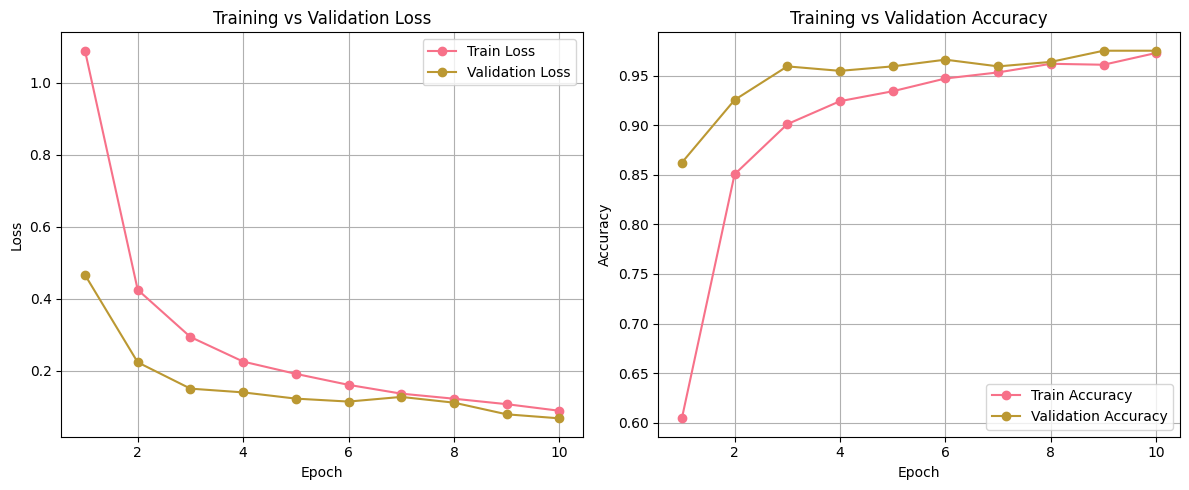

In [6]:
import matplotlib.pyplot as plt

train_loss = history['train_loss']
val_loss = history['val_loss']
train_acc = history['train_acc']
val_acc = history['val_acc']

epochs = range(1, 11)

plt.figure(figsize=(12,5))

# Loss plot
plt.subplot(1,2,1)
plt.plot(epochs, train_loss, marker='o', label='Train Loss')
plt.plot(epochs, val_loss, marker='o', label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.grid(True)

# Accuracy plot
plt.subplot(1,2,2)
plt.plot(epochs, train_acc, marker='o', label='Train Accuracy')
plt.plot(epochs, val_acc, marker='o', label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig("visualizations/classification/training_curves.png", dpi=300, bbox_inches='tight')

plt.show()


## Evaluation on Test Set

In [7]:
test_metrics = evaluator.evaluate_classification(model, test_loader)
print(test_metrics)
metrics_path = 'models/classification/metrics/test_metrics.json'
with open(metrics_path, 'w') as f:
    json.dump(test_metrics, f, indent=2)
print('Saved test metrics to', metrics_path)

{'accuracy': 0.9629213483146067, 'precision': 0.9630377971187278, 'recall': 0.9629213483146067, 'f1_score': 0.9629115922308986, 'precision_per_class': [0.9251700680272109, 0.9943820224719101, 0.97, 0.968421052631579, 0.9485714285714286], 'recall_per_class': [0.9251700680272109, 0.9672131147540983, 0.9897959183673469, 0.9787234042553191, 0.9431818181818182], 'f1_per_class': [0.9251700680272109, 0.9806094182825484, 0.9797979797979798, 0.9735449735449735, 0.9458689458689459], 'confusion_matrix': [[136, 1, 0, 3, 7], [2, 177, 2, 1, 1], [1, 0, 194, 1, 0], [1, 0, 2, 184, 1], [7, 0, 2, 1, 166]], 'num_samples': 890, 'num_classes': 5}
Saved test metrics to models/classification/metrics/test_metrics.json


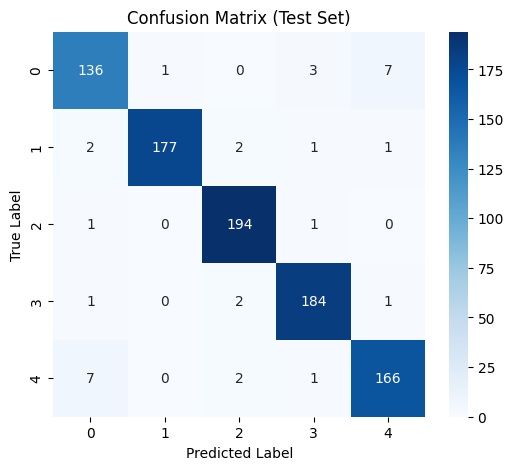

In [8]:
import seaborn as sns

conf_matrix = test_metrics['confusion_matrix']
# classes = data_loader.get_classes()

plt.figure(figsize=(6,5))

sns.heatmap(
    conf_matrix,
    annot=True,
    fmt="d",
    cmap="Blues"
    # xticklabels=classes,  
    # yticklabels=classes
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix (Test Set)")

plt.show()

In [9]:
# x = np.arange(len(classes))
# width = 0.25

# plt.figure(figsize=(8,5))

# plt.bar(x - width, precision_per_class, width, label="Precision")
# plt.bar(x, recall_per_class, width, label="Recall")
# plt.bar(x + width, f1_per_class, width, label="F1-score")

# plt.xticks(x, classes)
# plt.ylim(0,1.05)

# plt.ylabel("Score")
# plt.title("Per-class Metrics (Test Set)")
# plt.legend()
# plt.grid(axis="y")

# plt.show()